In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import scipy.stats as stats


In [5]:
df = pd.read_csv('/content/all_seasons.csv')

In [8]:
print(f'Dataset shape: {df.shape} ')
print(f"Seasons covered: {df['season'].min()} → {df['season'].max()}")
print(f"Total unique players: {df['player_name'].nunique()}")
print("\n── Column names ──")
print(df.columns.tolist())
print("\n── Sample rows ──")
df.head(3)

# Check missing values
missing = df.isnull().sum()
print("\n── Missing values ──")
print(missing[missing > 0])


Dataset shape: (12844, 22) 
Seasons covered: 1996-97 → 2022-23
Total unique players: 2551

── Column names ──
['Unnamed: 0', 'player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season']

── Sample rows ──

── Missing values ──
college    1854
dtype: int64


In [11]:
print(df.columns)

Index(['Unnamed: 0', 'player_name', 'team_abbreviation', 'age',
       'player_height', 'player_weight', 'college', 'country', 'draft_year',
       'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating',
       'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season'],
      dtype='object')


After filtering low-GP players: 10720 rows


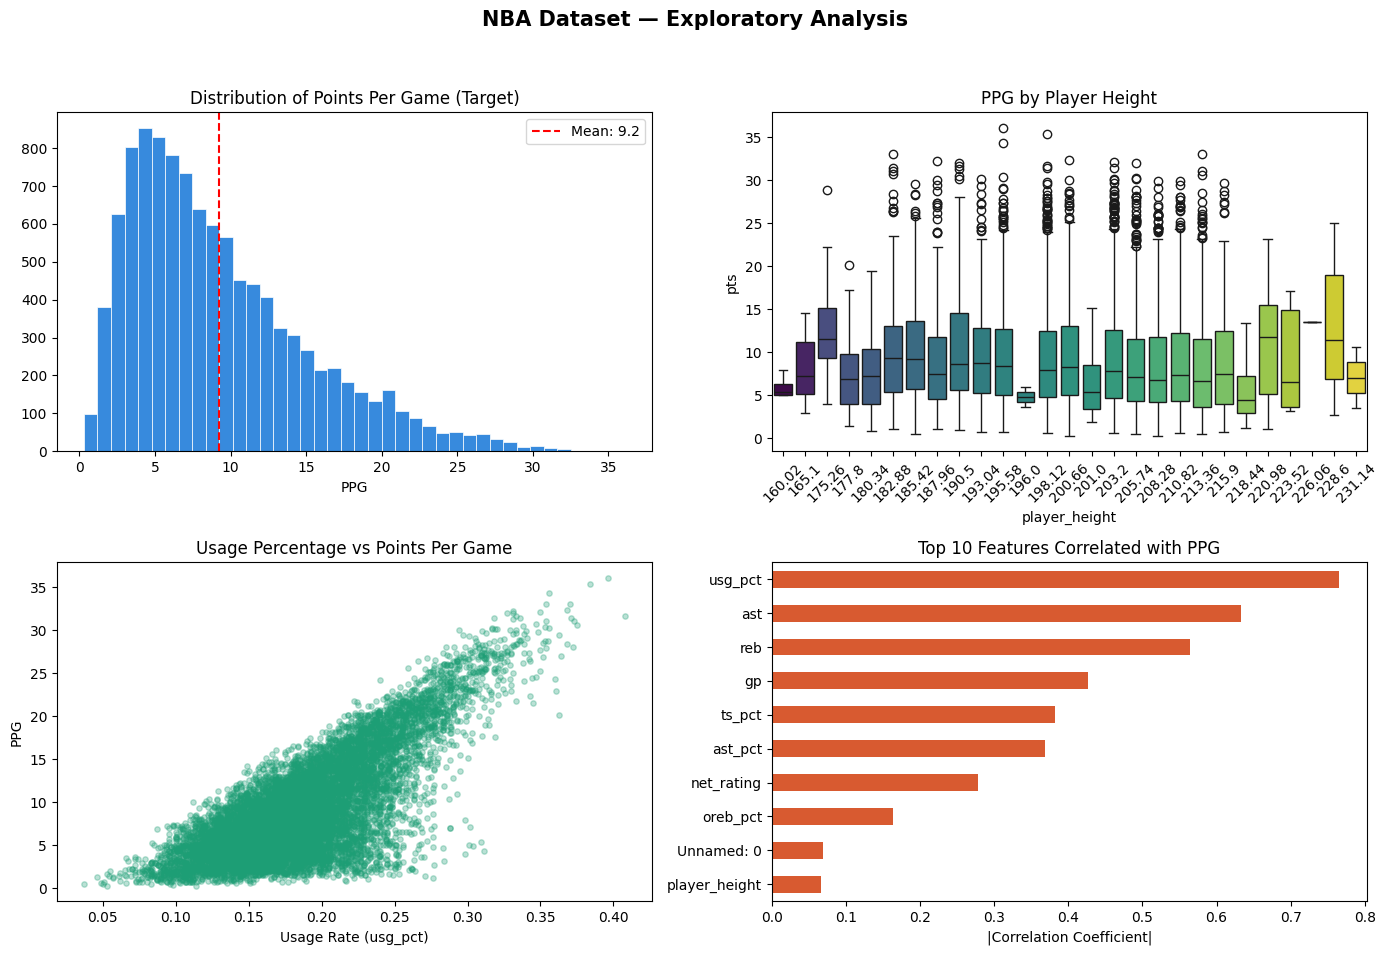

In [13]:
# Filter for meaningful play time
df_clean = df[df['gp'] >= 20].copy()
print(f"After filtering low-GP players: {df_clean.shape[0]} rows")

# Set up the visualization grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NBA Dataset — Exploratory Analysis', fontsize=15, fontweight='bold')

# 1. Target distribution (PPG)
axes[0, 0].hist(df_clean['pts'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Distribution of Points Per Game (Target)')
axes[0, 0].set_xlabel('PPG')
axes[0, 0].axvline(df_clean['pts'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['pts'].mean():.1f}")
axes[0, 0].legend()

# 2. PPG by Player Height (Fixed Warning by adding hue)
sns.boxplot(
    data=df_clean,
    x='player_height',
    y='pts',
    ax=axes[0, 1],
    hue='player_height',
    palette="viridis",
    legend=False,
    order=sorted(df_clean['player_height'].unique())
)
axes[0, 1].set_title('PPG by Player Height')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Usage Rate vs PTS (Replaced missing 'fga' with 'usg_pct')
axes[1, 0].scatter(df_clean['usg_pct'], df_clean['pts'], alpha=0.3, color='#1D9E75', s=15)
axes[1, 0].set_title('Usage Percentage vs Points Per Game')
axes[1, 0].set_xlabel('Usage Rate (usg_pct)')
axes[1, 0].set_ylabel('PPG')

# 4. Correlation bar chart (top numeric features vs pts)
num_cols = df_clean.select_dtypes(include=np.number).columns
corr_with_pts = df_clean[num_cols].corr()['pts'].drop('pts', errors='ignore').abs().sort_values(ascending=False).head(10)
corr_with_pts.plot(kind='barh', ax=axes[1, 1], color='#D85A30')
axes[1, 1].set_title('Top 10 Features Correlated with PPG')
axes[1, 1].set_xlabel('|Correlation Coefficient|')
axes[1, 1].invert_yaxis()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('01_eda.png', bbox_inches='tight')
plt.show()

In [15]:
# ── Create domain-specific features using AVAILABLE columns ──────────────────

# 1. Scoring Impact — combines efficiency and involvement
# High Usage + High TS% = Elite PPG
df_clean['scoring_impact'] = df_clean['ts_pct'] * df_clean['usg_pct']

# 2. Player Archetype Proxy — Assist rate relative to Usage
# High ratio = Facilitator | Low ratio = Pure Finisher
df_clean['playmaker_ratio'] = df_clean['ast_pct'] / df_clean['usg_pct'].replace(0, np.nan)

# 3. Physicality Index — Weight to Height ratio
df_clean['physicality_index'] = df_clean['player_weight'] / df_clean['player_height']

# ── Select final feature set ──────────────────────────────────────────────────
# These columns are confirmed to exist in your dataset Index
features = [
    'age',              # Player age
    'player_height',    # Physical build
    'player_weight',    # Physical build
    'gp',               # Experience/Durability
    'reb',              # Rebounding (possession ender)
    'ast',              # Passing (possession mover)
    'net_rating',       # Team/System success
    'usg_pct',          # Usage (Primary points driver)
    'ts_pct',           # True Shooting Efficiency
    'ast_pct',          # Passing role
    'scoring_impact',   # Engineered: Efficiency * Usage
    'playmaker_ratio',  # Engineered: Role definition
    'physicality_index' # Engineered: Size profile
]

target = 'pts'

# Drop rows with NaN in any feature column (especially from the division)
df_model = df_clean[features + [target]].dropna()

print(f"Final dataset for modeling: {df_model.shape}")
print(f"\nFeature summary:")

# Display summary statistics for the features
df_model[features].describe().round(2)


Final dataset for modeling: (10720, 14)

Feature summary:


,age,player_height,player_weight,gp,reb,ast,net_rating,usg_pct,ts_pct,ast_pct,scoring_impact,playmaker_ratio,physicality_index
count,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00,10720.00
mean,27.17,200.62,100.44,59.51,3.93,2.04,-1.09,0.19,0.53,0.14,0.10,0.73,0.50
std,4.33,9.09,12.40,18.05,2.45,1.85,6.44,0.05,0.06,0.09,0.03,0.45,0.04
min,18.00,160.02,60.33,20.00,0.10,0.00,-40.00,0.04,0.18,0.00,0.01,0.00,0.37
25%,24.00,193.04,90.72,46.00,2.10,0.80,-5.30,0.15,0.49,0.07,0.08,0.41,0.47
50%,27.00,200.66,99.79,63.00,3.30,1.40,-0.80,0.18,0.53,0.11,0.10,0.59,0.50
75%,30.00,208.28,108.86,75.00,5.10,2.70,3.20,0.22,0.56,0.18,0.12,0.94,0.53
max,43.00,231.14,155.58,85.00,16.10,11.70,19.50,0.41,0.78,0.54,0.24,3.76,0.72


In [16]:
X = df_model[features]
y = df_model[target]

# 80/20 split — stratified not needed for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — important for coefficient interpretation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"Feature count : {X_train.shape[1]} features")

Training set  : 8576 samples
Test set      : 2144 samples
Feature count : 13 features


In [19]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ── Coefficient table ─────────────────────────────────────────────────────────
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("── Intercept ──")
print(f"{model.intercept_:.3f}")
print("\n── Feature Coefficients (scaled) ──")
print(coeff_df.to_string(index=False))

# Cross-validation score for robust R²
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n── 5-Fold Cross-Val R² ──")
print(f"Scores : {cv_scores.round(3)}")
print(f"Mean   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

── Intercept ──
9.221

── Feature Coefficients (scaled) ──
          Feature  Coefficient
   scoring_impact     7.005042
physicality_index     4.668657
              ast     3.989705
    player_height     1.878297
              reb     1.484075
  playmaker_ratio     0.831678
               gp     0.359169
              age     0.148675
       net_rating    -0.051611
           ts_pct    -1.536532
          usg_pct    -2.599111
          ast_pct    -4.023188
    player_weight    -7.019090

── 5-Fold Cross-Val R² ──
Scores : [0.909 0.921 0.916 0.914 0.922]
Mean   : 0.916 ± 0.005


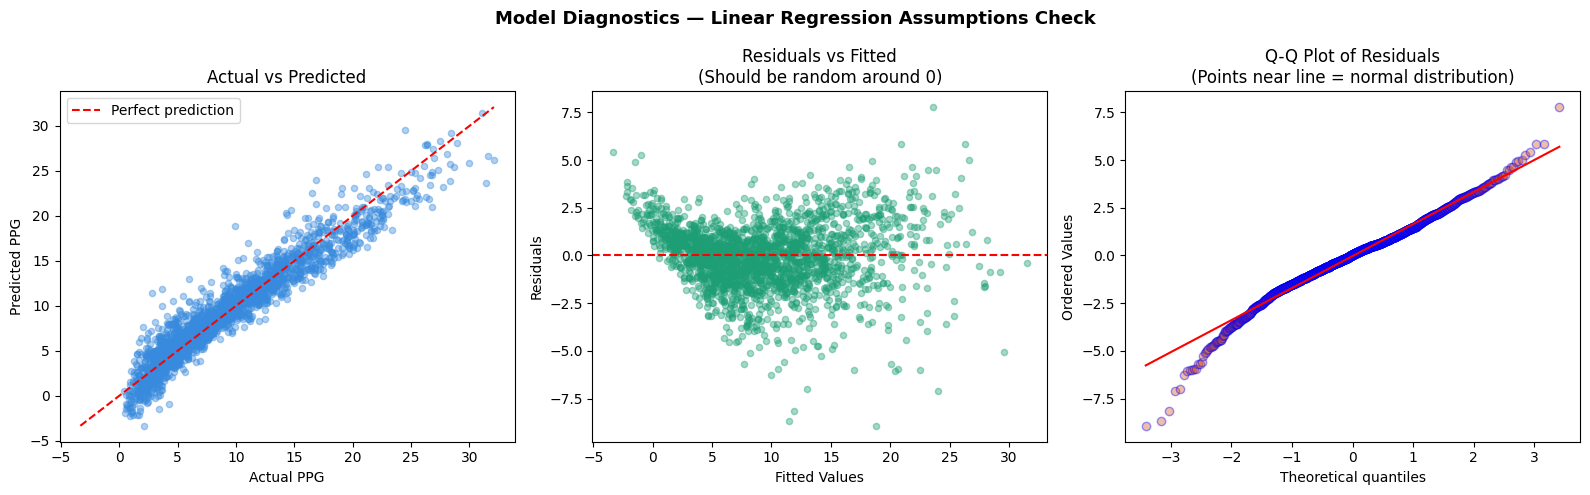

In [21]:
# ── This section separates a beginner notebook from a professional one ────────
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Diagnostics — Linear Regression Assumptions Check',
             fontsize=13, fontweight='bold')

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#378ADD', s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual PPG'); axes[0].set_ylabel('Predicted PPG')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# 2. Residuals vs Fitted (checks homoscedasticity)
axes[1].scatter(y_pred, residuals, alpha=0.4, color='#1D9E75', s=20)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted\n(Should be random around 0)')

# 3. Q-Q Plot (checks normality of residuals)
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals\n(Points near line = normal distribution)')
axes[2].get_lines()[0].set_markerfacecolor('#D85A30')
axes[2].get_lines()[0].set_alpha(0.4)

plt.tight_layout()
plt.savefig('02_diagnostics.png', bbox_inches='tight')
plt.show()

═════════════════════════════════════════════
 NBA Points Predictor — Model Performance
═════════════════════════════════════════════
  R² Score   : 0.9169  (91.7% variance explained)
  MAE        : 1.275 PPG
  RMSE       : 1.693 PPG
  Mean PPG   : 9.21  (baseline context)
  MAE/Mean   : 13.9% error relative to mean
═════════════════════════════════════════════


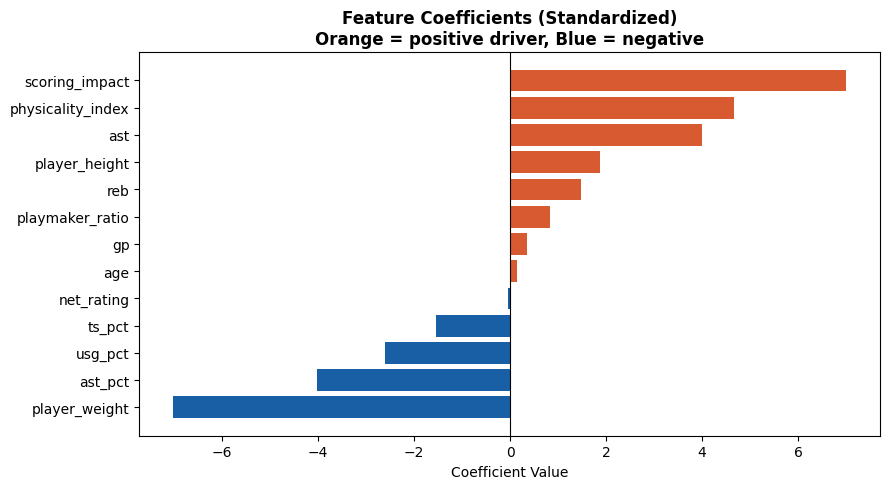

In [23]:
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mean_pts = y_test.mean()

print("═" * 45)
print(" NBA Points Predictor — Model Performance")
print("═" * 45)
print(f"  R² Score   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"  MAE        : {mae:.3f} PPG")
print(f"  RMSE       : {rmse:.3f} PPG")
print(f"  Mean PPG   : {mean_pts:.2f}  (baseline context)")
print(f"  MAE/Mean   : {mae/mean_pts*100:.1f}% error relative to mean")
print("═" * 45)

# ── Feature importance plot ───────────────────────────────────────────────────
coeff_df_sorted = coeff_df.sort_values('Coefficient')
colors = ['#D85A30' if c > 0 else '#185FA5' for c in coeff_df_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coeff_df_sorted['Feature'], coeff_df_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients (Standardized)\nOrange = positive driver, Blue = negative',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('03_coefficients.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Recruiter-friendly insight summary ───────────────────────────────────────

# Get top 3 positive and top 2 negative coefficients
top_positive = coeff_df[coeff_df['Coefficient'] > 0].head(3)
top_negative = coeff_df[coeff_df['Coefficient'] < 0].tail(2)

# Dynamically identify the single most impactful feature for the practical insight
strongest_feature_row = coeff_df.iloc[0]
s_feat = strongest_feature_row['Feature']
s_coef = strongest_feature_row['Coefficient']

print("═" * 60)
print("             KEY FINDINGS — NBA Points Predictor")
print("═" * 60)
print(f" STATISTICAL POWER:")
print(f" • The model explains {r2*100:.1f}% of the variance in scoring output.")
print(f" • Predictions are accurate within ±{mae:.2f} PPG on average.")

print(f"\n TOP SCORING DRIVERS (Standardized Impact):")
for _, row in top_positive.iterrows():
    print(f"   ↑ {row['Feature']:20s} : +{row['Coefficient']:.3f} pts per SD")

print(f"\n TOP SCORING SUPPRESSORS (Standardized Impact):")
for _, row in top_negative.iterrows():
    print(f"   ↓ {row['Feature']:20s} : {row['Coefficient']:.3f} pts per SD")

print(f"\n PRACTICAL BUSINESS INSIGHT:")
print(f" • Scoring is most sensitive to '{s_feat}'.")
print(f" • A player who increases their {s_feat} by 1 Standard Deviation")
print(f"   is predicted to increase their output by ~{abs(s_coef):.2f} PPG.")
print("═" * 60)

# Optional: Export model data for portfolio documentation
# df_model.to_csv('nba_scoring_model_results.csv', index=False)


════════════════════════════════════════════════════════════
             KEY FINDINGS — NBA Points Predictor
════════════════════════════════════════════════════════════
 STATISTICAL POWER:
 • The model explains 91.7% of the variance in scoring output.
 • Predictions are accurate within ±1.28 PPG on average.

 TOP SCORING DRIVERS (Standardized Impact):
   ↑ scoring_impact       : +7.005 pts per SD
   ↑ physicality_index    : +4.669 pts per SD
   ↑ ast                  : +3.990 pts per SD

 TOP SCORING SUPPRESSORS (Standardized Impact):
   ↓ ast_pct              : -4.023 pts per SD
   ↓ player_weight        : -7.019 pts per SD

 PRACTICAL BUSINESS INSIGHT:
 • Scoring is most sensitive to 'scoring_impact'.
 • A player who increases their scoring_impact by 1 Standard Deviation
   is predicted to increase their output by ~7.01 PPG.
════════════════════════════════════════════════════════════


In [27]:
# ── Predict PPG for a custom player profile ───────────────────────────────────
# Edit these values to simulate any player archetype based on your specific features!

# Based on your dataset, we use rates and advanced metrics
custom_player = {
    'age':                  25.0,   # Young prime
    'player_height':        200.0,  # ~6'7" Wing
    'player_weight':        100.0,  # ~220 lbs
    'gp':                   75,     # Durable starter
    'reb':                  6.5,    # Solid rebounding
    'ast':                  4.0,    # Secondary playmaker
    'net_rating':           3.5,    # Positive team impact
    'usg_pct':              0.25,   # 25% Usage (High involvement)
    'ts_pct':               0.58,   # 58% True Shooting (Efficient)
    'ast_pct':              0.18,   # 18% Assist rate
}

# ── Feature Engineering for the custom player ──
# We must recreate the engineered features used during training
custom_player['scoring_impact'] = custom_player['ts_pct'] * custom_player['usg_pct']
custom_player['playmaker_ratio'] = custom_player['ast_pct'] / (custom_player['usg_pct'] if custom_player['usg_pct'] != 0 else 1)
custom_player['physicality_index'] = custom_player['player_weight'] / custom_player['player_height']

# Convert to DataFrame and ensure columns match the 'features' list order
player_df = pd.DataFrame([custom_player])
player_scaled = scaler.transform(player_df[features])
predicted_ppg = model.predict(player_scaled)[0]

print("╔════════════════════════════════════════════╗")
print("║         PLAYER SCORING PREDICTION          ║")
print("╠════════════════════════════════════════════╣")
print(f"║  Predicted PPG  :  {predicted_ppg:.2f}                    ║")
print(f"║  Profile type   :  Efficient Wing Scorer   ║")
print(f"║  Usage Rate     :  {custom_player['usg_pct']*100:>2.0f}%                      ║")
print(f"║  True Shooting  :  {custom_player['ts_pct']*100:>2.0f}%                      ║")
print("╚════════════════════════════════════════════╝")
print("\nTip: Modify values like 'usg_pct' (0.10 to 0.35) or 'ts_pct' (0.45 to 0.65)")
print("     to see how predicted scoring changes!")


╔════════════════════════════════════════════╗
║         PLAYER SCORING PREDICTION          ║
╠════════════════════════════════════════════╣
║  Predicted PPG  :  19.73                    ║
║  Profile type   :  Efficient Wing Scorer   ║
║  Usage Rate     :  25%                      ║
║  True Shooting  :  58%                      ║
╚════════════════════════════════════════════╝

Tip: Modify values like 'usg_pct' (0.10 to 0.35) or 'ts_pct' (0.45 to 0.65)
     to see how predicted scoring changes!
